In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#workclass - Private, Self-emp-not-inc, Local-gov, State-gov
#marital.status - Married-civ-spouse, Widowed, Divorced, Separated	
#occupation - Exec-managerial, Machine-op-inspct, Prof-specialty, Sales, Adm-clerical, Craft-repair
#relationship - Not-in-family, Unmarried, Own-child	, Husband, wife
#race - White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo
#fnlwgt - Final Weight

In [3]:
df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.shape

(32561, 15)

In [5]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

<Axes: xlabel='age', ylabel='workclass'>

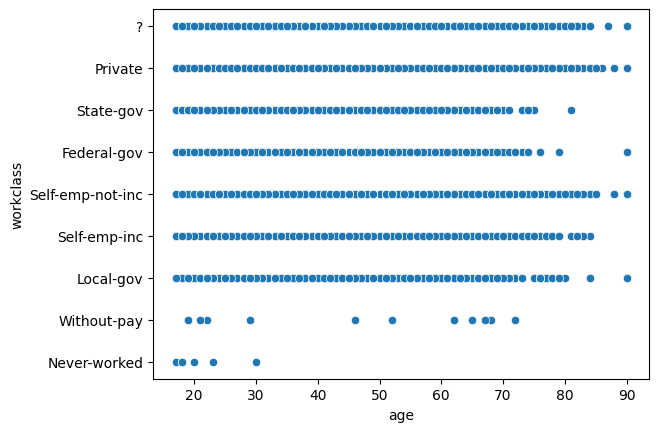

In [6]:
sns.scatterplot(x = 'age', y = 'workclass', data = df)

<Axes: xlabel='education', ylabel='workclass'>

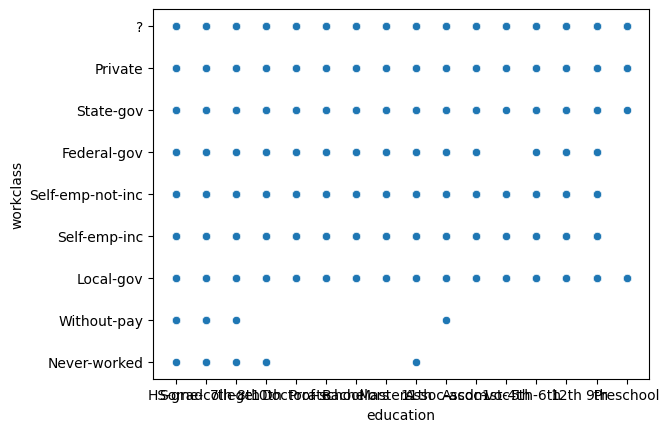

In [7]:
sns.scatterplot(x = 'education', y = 'workclass', data = df)

<Axes: xlabel='age', ylabel='occupation'>

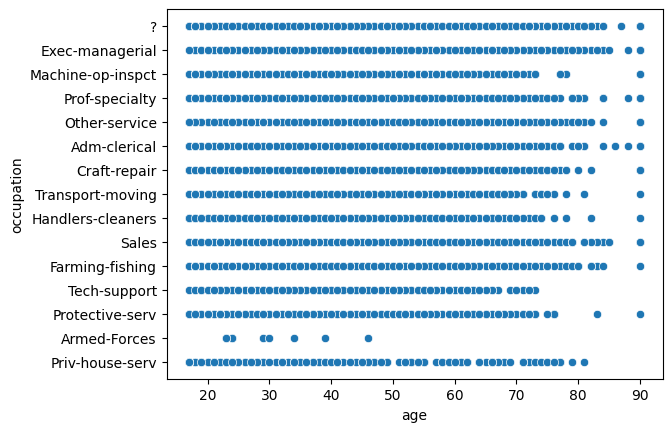

In [8]:
sns.scatterplot(x = 'age', y = 'occupation', data = df)

<Axes: xlabel='education', ylabel='occupation'>

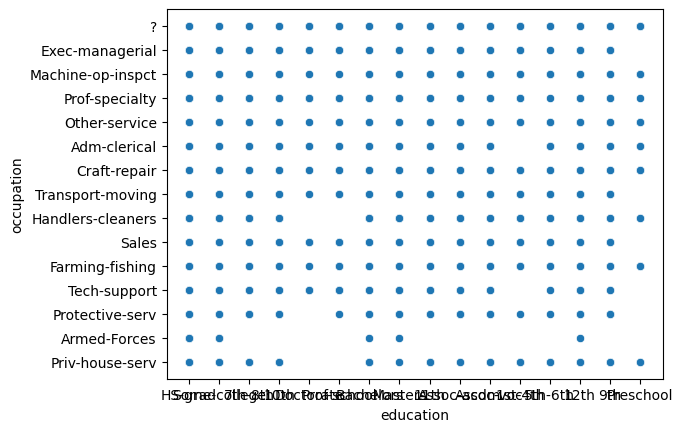

In [9]:
sns.scatterplot(x = 'education', y = 'occupation', data = df)

<Axes: xlabel='workclass', ylabel='occupation'>

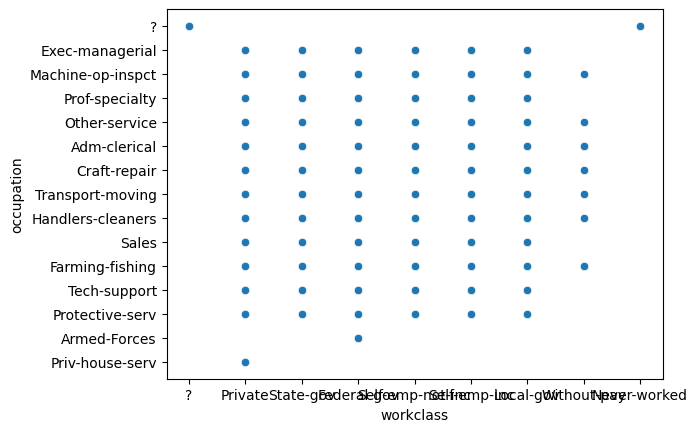

In [10]:
sns.scatterplot(x = 'workclass', y = 'occupation', data = df)

In [11]:
mask_never_worked = df['workclass'] == 'Never-worked'
df.loc[mask_never_worked, 'occupation'] = 'Never-worked'

mask_missing = (df['workclass'] == '?') & (df['occupation'] == '?')
df.loc[mask_missing, ['workclass', 'occupation']] = 'Unknown'

In [12]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Unknown,77053,HS-grad,9,Widowed,Unknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Unknown,186061,Some-college,10,Widowed,Unknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


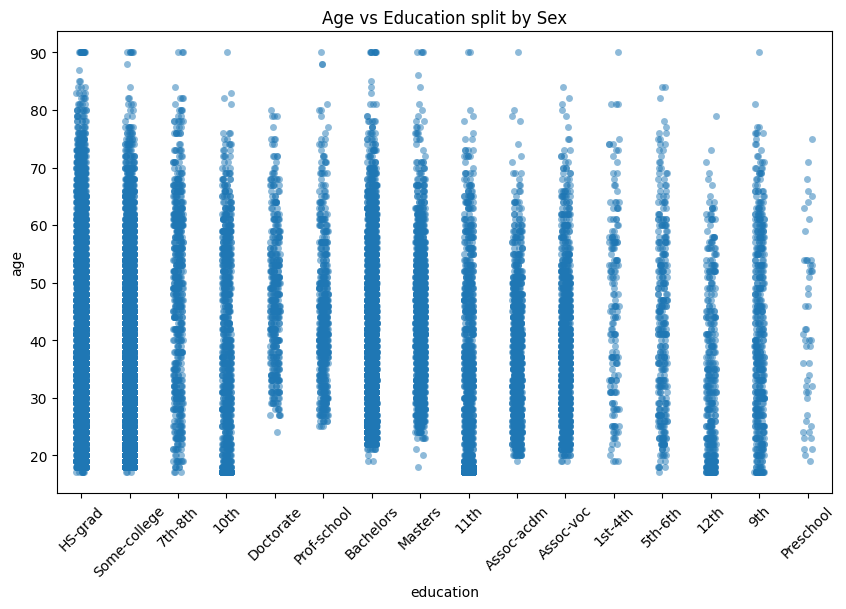

In [13]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    x='education',
    y='age',
    data=df,
    dodge=True,
    alpha=0.5
)
plt.xticks(rotation=45)
plt.title('Age vs Education split by Sex')
plt.show()

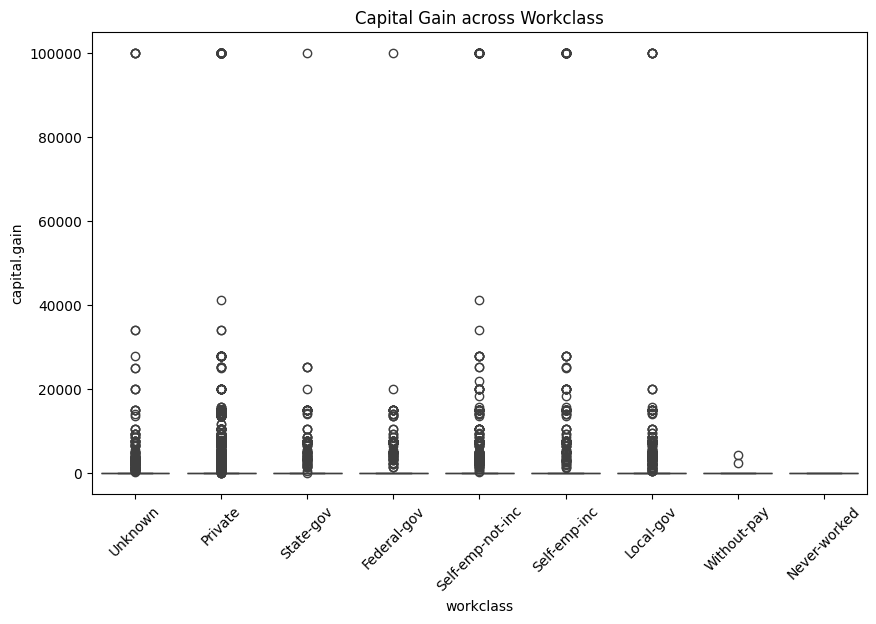

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='workclass',
    y='capital.gain',
    data=df
)
plt.xticks(rotation=45)
plt.title('Capital Gain across Workclass')
plt.show()


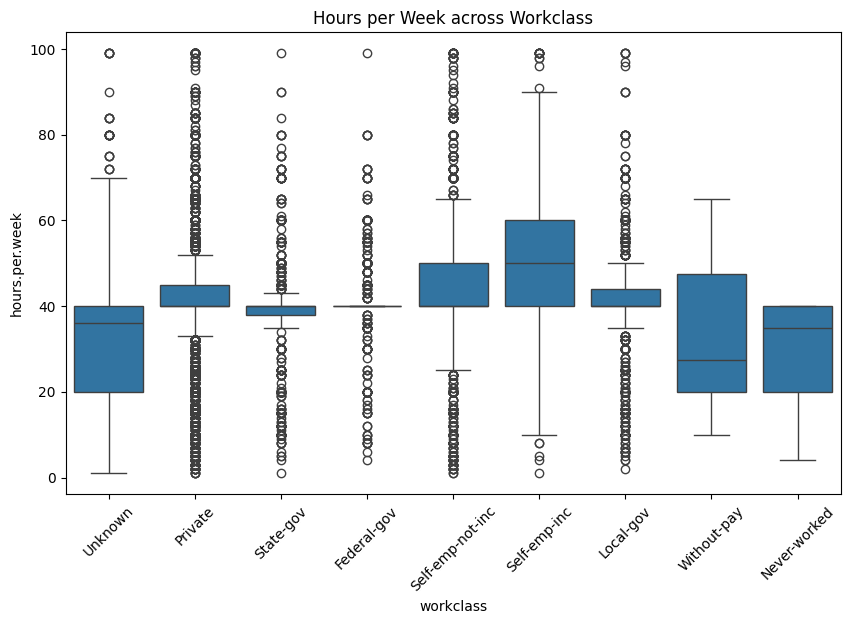

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='workclass',
    y='hours.per.week',
    data=df
)
plt.xticks(rotation=45)
plt.title('Hours per Week across Workclass')
plt.show()


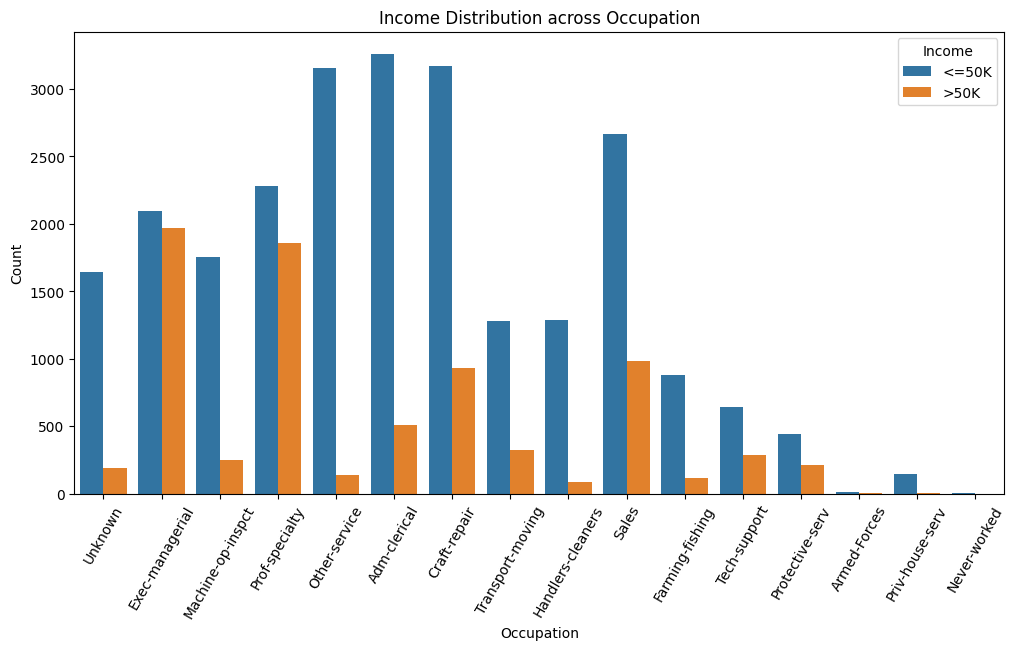

In [16]:
plt.figure(figsize=(12, 6))
sns.countplot(
    x='occupation',
    hue='income',
    data=df
)
plt.xticks(rotation=60)
plt.title('Income Distribution across Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.legend(title='Income')
plt.show()

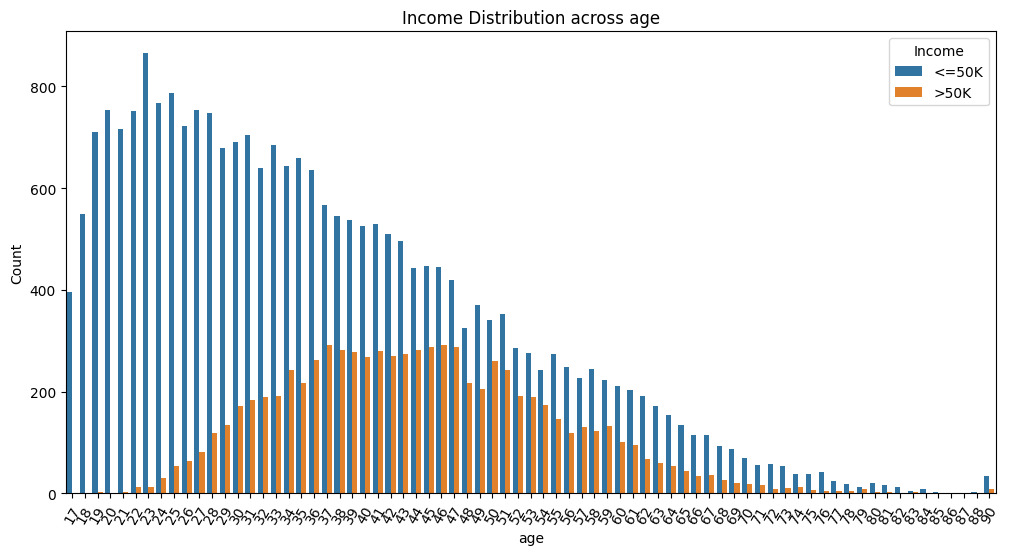

In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(
    x='age',
    hue='income',
    data=df
)
plt.xticks(rotation=60)
plt.title('Income Distribution across age')
plt.xlabel('age')
plt.ylabel('Count')
plt.legend(title='Income')
plt.show()

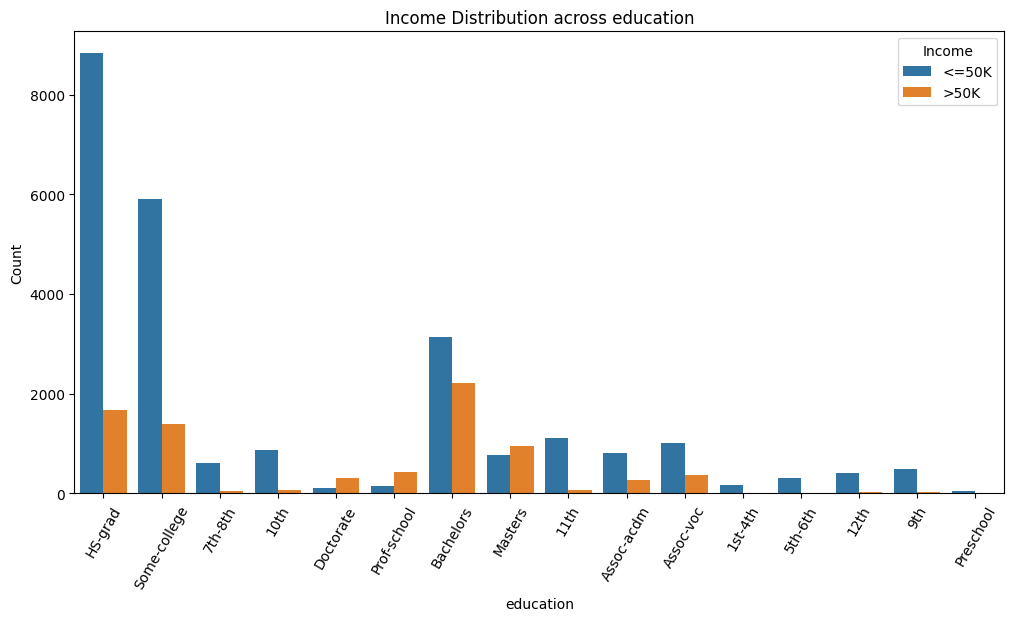

In [18]:
plt.figure(figsize=(12, 6))
sns.countplot(
    x='education',
    hue='income',
    data=df
)
plt.xticks(rotation=60)
plt.title('Income Distribution across education')
plt.xlabel('education')
plt.ylabel('Count')
plt.legend(title='Income')
plt.show()

In [19]:
X = df.drop(columns = 'income')
y = df['income']

print(X.shape)
print(y.shape)

(32561, 14)
(32561,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(26048, 14)
(6513, 14)
(26048,)
(6513,)


In [21]:
# Define categorical and numeric columns

categorical_cols = [
    'workclass',
    'education',
    'marital.status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native.country'
]

numeric_cols = [
    'age',
    'fnlwgt',
    'education.num',
    'capital.gain',
    'capital.loss',
    'hours.per.week'
]

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [22]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

print(type(X_train_encoded))

(26048, 100)
(6513, 100)
<class 'numpy.ndarray'>


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model (controlled depth)
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train
model.fit(X_train_encoded, y_train)

# Predict
y_pred = model.predict(X_test_encoded)


In [24]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Accuracy: 0.8492246276677414
Confusion Matrix:
[[4707  238]
 [ 744  824]]


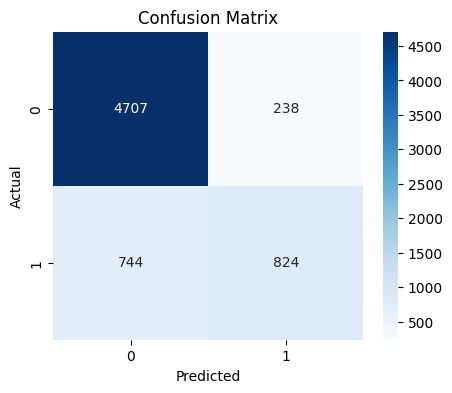

In [25]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
##check for overfitting

model.score(X_train_encoded, y_train)

0.8528101965601965

In [29]:
# Create model (controlled depth)
model = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train
model.fit(X_train_encoded, y_train)

# Predict
y_pred = model.predict(X_test_encoded)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)



Accuracy: 0.7742975587286964
Confusion Matrix:
[[3662 1283]
 [ 187 1381]]


In [30]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=200,      # number of trees
    max_depth=None,        # allow trees to grow
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1              # use all cores
)

# Train
rf_model.fit(X_train_encoded, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_encoded)

In [31]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

Accuracy: 0.8587440503608168


In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)


Confusion Matrix:
[[4668  277]
 [ 643  925]]


In [33]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,      # number of trees
    max_depth=None,        # allow trees to grow
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1              # use all cores
)

# Train
rf_model.fit(X_train_encoded, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_encoded)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)


Accuracy: 0.8179026562260096
Confusion Matrix:
[[4013  932]
 [ 254 1314]]
